<h1><center> TD Python chimie partie B</center></h1>

**Capacités numériques chapitres B2 et B3 PCSI** : 

- déterminer, à l’aide d’un langage de programmation, l’état final d’un système, siège d’une transformation, modélisée par une réaction à partir des conditions initiales et de la valeur de la constante thermodynamique d’équilibre.
- à l’aide d’un langage de programmation et à partir de données expérimentales, tracer l’évolution temporelle d’une concentration, d’une vitesse volumique de formation ou de consommation, d’une vitesse de réaction et tester une loi de vitesse donnée.

Pour cela nous allons utiliser :
- la méthode <b>dichotomique</b> pour résoudre une équation f(x)=0 avec la fonction <b>bisect</b> de la bibliothèque <b>scipy.optimize</b>.
- les fonctions de la bibliothèque <b>matplotlib</b> pour donner la représentation graphique d'une fonction ou d'un nuage de points et rendre le graphique exploitable (présence d’une légende, choix des échelles...).
- la fonction <b>polyfit</b> de la bibliothèque <b>numpy</b> pour exploiter des données par regression linéaire.

<h2>Chapitre B2 : Equilibres</h2>

L’éthanol est un réactif mais aussi un solvant couramment utilisé en chimie organique. Il est possible de fabriquer industriellement l’éthanol par hydratation de l’éthylène (ou éthène), issu du vapocraquage d’hydrocarbures, en présence d’un catalyseur acide (procédé Shell). Cette réaction conduit à un équilibre de constante d’équilibre K :

<center>H<sub>2</sub>C=CH<sub>2</sub> <sub>(g)</sub>	+	H<sub>2</sub>O <sub>(g)</sub>	=	CH<sub>3</sub>-CH<sub>2</sub>OH <sub>(g)</sub>       </center>

On introduit initialement, à une température fixée à 400 K et sous une pression maintenue à 1,00 bar, 1,00 mole d’éthylène gazeux et 1,00 mole d’eau gazeuse. On nomme alpha le taux d'avancement (égal à la fraction d’éthylène transformée à l’équilibre). 

De plus la constante d’équilibre K vérifie la loi suivante :

<center>ln K = (5480/T) - 15,2  (avec T en kelvins)</center>

**Exercice 1 : Calcul d'un taux d'avancement** 

La fonction bisect de la bibliothèque scipy.optimize permet de trouver par dichotomie la solution d'une fonction f(x)=0 pour x compris dans un intervale [a,b] en réduisant petit à petit l'intervalle de solution par le milieu. 

Déterminer l’équation à résoudre pour trouver alpha par méthode dichotomique, puis compléter le script suivant pour trouver la valeur de alpha pour une pression totale de 1,00 bar puis de 100 bars. Commenter le résultat obtenu.

In [8]:
# importer la bibliothèque python nécessaire pour le calcul par dichotomie
import scipy.optimize as op
import numpy as np

K = np.exp((5480/400) - 15.2) # valeur de la constante d'équilibre à 400 K
P = 100 #A COMPLETER # bar # valeur de la pression totale en bar
Pstand = 1.00 #A COMPLETER # bar # valeur de la pression standard en bar

# définition d'une fonction qui s'annule à l'équilibre pour calculer alpha
def f(alpha) :
    return ( alpha * (2-alpha) * Pstand ) / ( ((1-alpha)**2) * P ) - K
        
a=1e-9#A COMPLETER # borne inférieure de alpha
b=1-a#A COMPLETER # borne supérieure de alpha

# utilisation de la fonction bisect de la bibliothèque scipy.optimize : 
res = op.bisect(f, a, b)

print(res)


0.7928901429131


**Exercice 2 : Etude de l’influence de la pression sur cet équilibre.**

Compléter le script suivant pour tracer alpha en fonction de P, la pression totale pour P variant de 1 à 1000 bars, par pas de 1 bar, T étant toujours égal à 400K.

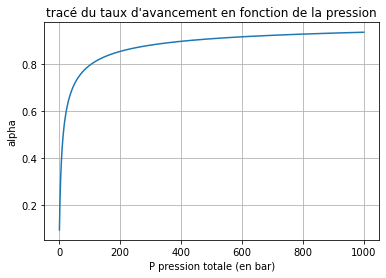

In [16]:
# importer les bibliothèques python nécessaires pour les calculs et tracés de graphiques
import scipy.optimize as op
import matplotlib.pyplot as plt
import numpy as np

K = np.exp((5480/400) - 15.2) #A COMPLETER # valeur de la constante d'équilibre à 400 K
Pstand = 1.0 #A COMPLETER #bar # valeur de la pression standard en bar

# création d'une liste de valeurs de P de 1000 éléments entre 1 et 1000 bars inclus (pas de 1 bar)
# np.linspace(valeur départ, valeur fin, nombre d'éléments)
Plist = np.linspace(1, 1000, 1000) #A COMPLETER

# définition d'une fonction qui s'annule à l'équilibre pour calculer alpha

def f(alpha, P) : 
    return ( alpha * (2-alpha) * Pstand ) / ( ((1-alpha)**2) * P ) - K #A COMPLETER

# création d'une liste de alpha par ajout de valeurs résultant du calcul de alpha par dichotomie avec K 
# pour chaque valeur de P dans Plist

a=1e-9 #A COMPLETER # borne inférieure de alpha
b=1-a #A COMPLETER # borne supérieure de alpha

alphalist = []
for P in Plist:
    alphalist.append( op.bisect(lambda x : f(x, P), a, b) )  #A COMPLETER)
# print(Plist)
# tracé du graphique alpha en fonction de P
# plt.plot(abscisses,ordonnées) plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées")
# plt.title("titre graphique")
plt.plot(Plist, alphalist)
plt.xlabel("P pression totale (en bar)")
plt.ylabel("alpha")
plt.title("tracé du taux d'avancement en fonction de la pression")
plt.grid()
plt.show()

**Exercice 3 : Etude de l’influence de la température sur cet équilibre.**

On veut tracer alpha en fonction de la température T variant de 201 à 500 kelvin, par pas de 1 K, pour P = 1.00 bar. 
Modifier le script précédent qui a été copié afin de tracer alpha(T) et commenter l'évolution obtenue.

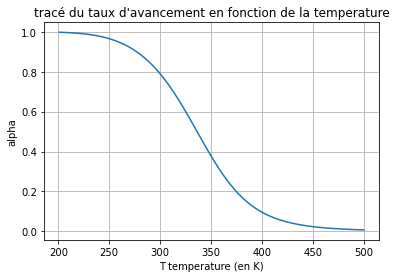

In [22]:
# importer les bibliothèques python nécessaires pour les calculs et tracés de graphiques
import scipy.optimize as op
import matplotlib.pyplot as plt
import numpy as np

T = np.linspace(201,500,300) #A COMPLETER # valeur de la constante d'équilibre à 400 K
Pstand=1.00 #A COMPLETER #bar # valeur de la pression standard en bar

# création d'une liste de valeurs de P de 1000 éléments entre 1 et 1000 bars inclus (pas de 1 bar)
# np.linspace(valeur départ, valeur fin, nombre d'éléments)
K = np.exp(5480/T - 15.2) #A COMPLETER
P = 1.0
# définition d'une fonction qui s'annule à l'équilibre pour calculer alpha
def f(alpha, k) : 
    return ( alpha * (2-alpha) * Pstand ) / ( ((1-alpha)**2) * P ) - k #A COMPLETER

# création d'une liste de alpha par ajout de valeurs résultant du calcul de alpha par dichotomie avec K 
# pour chaque valeur de P dans Plist

a= 1e-9 #A COMPLETER # borne inférieure de alpha
b= 1-a #A COMPLETER # borne supérieure de alpha

alphalist = []
for k in K:
    alphalist.append(op.bisect(lambda x : f(x, k), a, b))

# tracé du graphique alpha en fonction de P
# plt.plot(abscisses,ordonnées) plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées")
# plt.title("titre graphique")
plt.plot(T, alphalist)
plt.xlabel("T temperature (en K)")
plt.ylabel("alpha")
plt.title("tracé du taux d'avancement en fonction de la temperature")
plt.grid()
plt.show()


**Exercice 4 : Etude de l’influence de l’exces d’eau sur cet équilibre.**

On veut tracer alpha en fonction de n, le nombre de moles d’eau initial pour n variant de 1 à 100 moles par pas de 1 mole pour T = 400 K et P = 10 bar.
Modifier le script précédent qui a été copié afin de tracer alpha(n). Commenter.

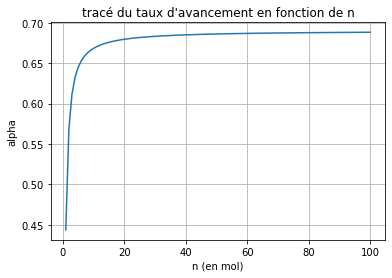

In [27]:
# importer les bibliothèques python nécessaires pour les calculs et tracés de graphiques
import scipy.optimize as op
import matplotlib.pyplot as plt
import numpy as np

T = 400 #A COMPLETER # valeur de la constante d'équilibre à 400 K
Pstand=1.00 #A COMPLETER #bar # valeur de la pression standard en bar

# création d'une liste de valeurs de P de 1000 éléments entre 1 et 1000 bars inclus (pas de 1 bar)
# np.linspace(valeur départ, valeur fin, nombre d'éléments)
K = np.exp(5480/T - 15.2) #A COMPLETER
P = 10.0
n0 = 1.0
nlist = np.linspace(1, 100, 100)

# définition d'une fonction qui s'annule à l'équilibre pour calculer alpha
def f(alpha, n) : 
    return ( (alpha * n0 * (n + n0 - alpha*n0) * Pstand) / (n0 * (1-alpha) * (n - alpha*n0) * P) ) - K #A COMPLETER

# création d'une liste de alpha par ajout de valeurs résultant du calcul de alpha par dichotomie avec K 
# pour chaque valeur de P dans Plist

a= 1e-9 #A COMPLETER # borne inférieure de alpha
b= 1-a #A COMPLETER # borne supérieure de alpha

alphalist = []
for n in nlist:
    alphalist.append(op.bisect(lambda x : f(x, n), a, b))

# tracé du graphique alpha en fonction de P
# plt.plot(abscisses,ordonnées) plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées")
# plt.title("titre graphique")
plt.plot(nlist, alphalist)
plt.xlabel("n (en mol)")
plt.ylabel("alpha")
plt.title("tracé du taux d'avancement en fonction de n")
plt.grid()
plt.show()


------
<h2>Chapitre B3 : Cinétique</h2>


A 45°C dans l'éthanol absolu, le benzène sulfonate d'éthyle A réagit avec l'éthylonate de sodium selon la réaction :  

<center>PhSO<sub>3</sub>Et + EtO<sup>-</sup> = PhSO<sub>3</sub><sup>-</sup> + EtOEt</center>
 
Les réactifs sont introduits en proportions stoechiométriques et on détermine la concentration de A qui reste au cours du temps :


t(min) :	0 / 20	/ 40 /	60	/ 80	/ 100	/ 120	/ 140	/ 160	/ 180

[A] (mol/L) : 0,050	/ 0,043	/ 0,038	/ 0,034	/ 0,030	/ 0,028	/ 0,025	/ 0,023	/ 0,022	/ 0,020


**Exercice 1 : Tracé des concentrations en fonction du temps**

Tracer [A] = f(t) en complétant le script suivant. On représentera les points expérimentaux par des points. 

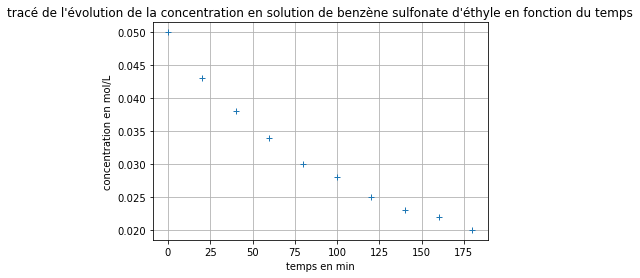

In [25]:
# importer les bibliothèques python nécessaires pour les tracés de graphiques
import matplotlib.pyplot as plt

# création des listes des abcisses t et ordonnées c
tlist=[0,20,40,60,80,100,120,140,160,180] #min
clist=[0.050,0.043,0.038,0.034,0.030,0.028,0.025,0.023,0.022,0.020] #mol/L

# tracé de la concentration en A en fonction du temps
# plt.plot(abscisses,ordonnées,"symbole du point") plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées")
# plt.title("titre graphique")
plt.plot(tlist,clist,'+')
plt.xlabel("temps en min")
plt.ylabel("concentration en mol/L")
plt.title("tracé de l'évolution de la concentration en solution de benzène sulfonate d'éthyle en fonction du temps")
plt.grid()
plt.show()


**Exercice 2 : méthode différentielle : détermination d’un ordre de réaction.**

Compléter le script suivant. Créer une liste des vitesses de réaction pour les temps 20 à 160 min et tracer v=f(t) (points représentés par des étoiles). 


Linéariser ensuite l'expression de la vitesse pour trouver un modèle de droite affine grâce à la fonction np.polyfit et tracer sur un même graphe les points expérimentaux (représentés par des points) et le modèle (représenté par des tirets).
Afficher les valeurs de l’ordre global de la réaction et de la constante cinétique.

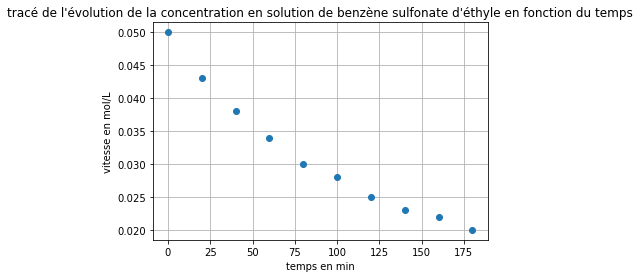

No handles with labels found to put in legend.


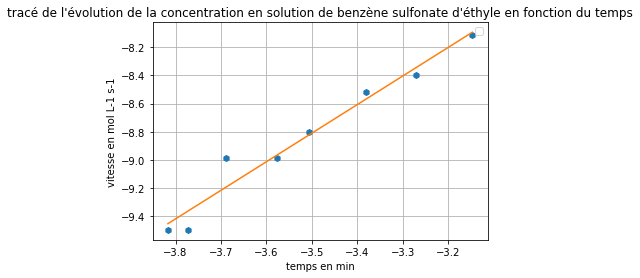

l'ordre global de la réaction est 2 et la constante cinétique de la réaction vaut 0.182 en L.mol-1.min-1


In [31]:
# importer les bibliothèques python nécessaires pour les calculs et tracés de graphiques
import numpy as np
import matplotlib.pyplot as plt

# création des listes des abcisses t et ordonnées c
tlist=[0,20,40,60,80,100,120,140,160,180] #min
clist=[0.050,0.043,0.038,0.034,0.030,0.028,0.025,0.023,0.022,0.020] #mol/L

# calcul des vitesses pour un point i à l'aide de la pente de la droite passant par les points i-1 et i+1
# (donc sans le premier et le dernier point i)
# len() pour obtenir le nombre d'élément d'une liste
vlist = []
N=len(tlist)
for i in range(1,N-1):
    vlist.append(-1 * (clist[i+1] - clist[i-1]) / (tlist[i+1] - tlist[i-1]) )

# création des listes réduites des abcisses t et ordonnées c sans le premier et le dernier point
tlistred=tlist[1:N-1]
clistred=clist[1:N-1]
    
# tracé de la vitesse en fonction du temps
# plt.plot(abscisses,ordonnées,"symbole du point") plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées")
# plt.title("titre graphique")
plt.plot(tlist,clist,'o')
plt.xlabel("temps en min")
plt.ylabel("vitesse en mol/L")
plt.title("tracé de l'évolution de la concentration en solution de benzène sulfonate d'éthyle en fonction du temps")
plt.grid()
plt.show()

# méthode différentielle : tracé de lnv en fonction de lnc 
# et modélisation affine avec pente = odre et ordonnée à l'origine = lnk

# création des listes de lnv et de lnc (pour liste de c réduite) avec np.log() pour ln

lnvlist = np.log(vlist)
#for v in vlist:
 #   lnvlist.append(#A COMPLETER)
    
lnclistred = np.log(clistred)
#for c in clistred:
#    lnclistred.append(#A COMPLETER)

# modélisation avec la fonction np.polyfit(x,y,deg) qui donne un tableau des coefficients a,b pour le modèle y=ax+b
# où deg est le degré du polynome de modélisation : ici 1 pour y=ax+b
# np.exp() pour exp
a,b=np.polyfit(lnclistred, lnvlist, 1)
k = np.exp(b)  #A COMPLETER
lnvmod=[a*x+b for x in lnclistred]

#tracés de lnv en fonction de lnc (pour liste réduite de c) et de la droite modèle
# plt.plot(abscisses,ordonnées,"symbole du point",label="titre légende" ) 
# plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées") plt.title("titre graphique")
# int(i) pour obtenir la valeur entière de i
# round(i,nombre de décimales) pour arrondir une valeur i avec un nombre de décimales donné 
plt.plot(lnclistred, lnvlist, 'o')
plt.plot(lnclistred, lnvmod)
plt.xlabel("temps en min")
plt.ylabel("vitesse en mol L-1 s-1")
plt.title("tracé de l'évolution de la concentration en solution de benzène sulfonate d'éthyle en fonction du temps")
plt.grid()
plt.legend()
plt.show()

print("l'ordre global de la réaction est",int(a),"et la constante cinétique de la réaction vaut",round(k,3),"en L.mol-1.min-1")

**Exercice 3 : méthode d’intégration : détermination de k pour un ordre 2.**

Compléter le script suivant pour valider un ordre global 2 par méthode intégrale. Tracer sur un même graphique les points expérimentaux (représentés par des points) et le modèle (représenté par des tirets) et afficher la valeur de la constante cinétique k.

Commenter les résultats des deux méthodes.  

No handles with labels found to put in legend.


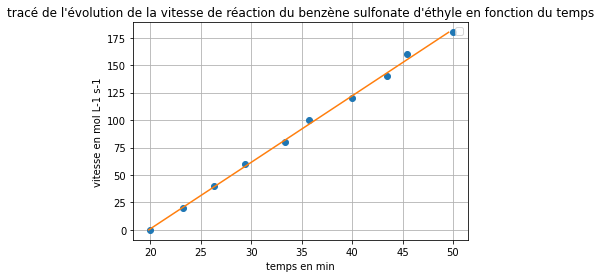

La constante cinétique de la réaction vaut 0.165 en L.mol-1.min-1


In [35]:
# importer les bibliothèques python nécessaires pour les calculs et tracés de graphiques
import numpy as np
import matplotlib.pyplot as plt

#création des listes des abcisses t et ordonnées c
tlist=[0,20,40,60,80,100,120,140,160,180] #min
clist=[0.050,0.043,0.038,0.034,0.030,0.028,0.025,0.023,0.022,0.020] #mol/L

# méthode intégrale pour ordre 2 : tracé de 1/c en fonction de t et modélisation affine avec pente = k

#création de la liste de 1/c
invclist = [1/c for c in clist]

# modélisation avec la fonction np.polyfit(x,y,deg) qui donne un tableau des coefficients a,b pour le modèle y=ax+b
# où deg est le degré du polynome de modélisation : ici 1 pour y=ax+b
a,b=np.polyfit(tlist, invclist, 1)
invcmod=[a*x+b for x in tlist]

# tracé de 1/c en fonction de t et de la droite modèle
# plt.plot(abscisses,ordonnées,"symbole du point",label="titre légende" ) 
# plt.xlabel("titre abcisses") plt.ylabel("titre ordonnées") plt.title("titre graphique")
# round(i,nombre de décimales) pour arrondir une valeur i avec un nombre de décimales donné 
plt.plot(invclist, tlist, 'o')
plt.plot(invcmod, tlist)
plt.xlabel("temps en min")
plt.ylabel("vitesse en mol L-1 s-1")
plt.title("tracé de l'évolution de la vitesse de réaction du benzène sulfonate d'éthyle en fonction du temps")
plt.grid()
plt.legend()
plt.show()

print("La constante cinétique de la réaction vaut",round(a,3),"en L.mol-1.min-1")